# Projet 1 : Détection de drones militaires avec YOLOv11 (dataset Roboflow)

Cours : Computer Vision, Examen

Ce notebook part de notre export Roboflow au format YOLOv11 (dossiers `train/`, `valid/`, `test/` et fichier `data.yaml`). La collecte, le contrôle qualité, l'annotation et le découpage ont été faits en amont sous Roboflow. Le notebook enchaîne directement sur :

1. Chargement de l'export Roboflow
2. Data augmentation (intégrée à YOLO)
3. Entraînement de YOLOv11
4. Évaluation (Precision, Recall, mAP@50, mAP@50-95, matrice de confusion)
5. Démonstration sur images et vidéos inédites
6. Export du modèle entraîné

L'ensemble a été exécuté sur Google Colab avec un GPU T4.

## 0. Installation

In [ ]:
!pip install -q ultralytics

In [ ]:
import ultralytics, torch
ultralytics.checks()
print("GPU disponible :", torch.cuda.is_available())

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.2/112.6 GB disk)
GPU disponible : True


## 1. Chargement du jeu de données

Le jeu de données a été annoté sous Roboflow, puis re-découpé par le script `scripts/decouper_dataset.py` (voir section 1.1). L'archive `dataset.zip` contient la structure YOLO attendue : `train/`, `valid/`, `test/` et le fichier `data.yaml`.

### 1.1 Pourquoi un re-découpage

Le découpage aléatoire produit par Roboflow plaçait dans le jeu de test des frames extraites des mêmes vidéos que celles vues à l'entraînement, à une ou deux secondes d'intervalle. Ces images étant quasi identiques, le modèle les reconnaissait au lieu de généraliser, et les métriques étaient surévaluées.

Le nouveau découpage applique trois règles :

1. Toutes les frames d'une même vidéo restent en entraînement. La validation et le test ne contiennent que des photographies indépendantes.
2. Les photographies sont réparties de façon stratifiée par modèle de drone.
3. Les modèles qui n'ont qu'une seule image (ScanEagle, Tanan, Épervier) restent en entraînement : évaluer sur un type de drone jamais vu n'aurait pas de sens.

Répartition obtenue : 106 images d'entraînement, 18 de validation et 16 de test. Le détail image par image est traçable dans `split_audit.csv`.

In [ ]:
from pathlib import Path
import zipfile, glob

# Archive produite par resplit_dataset.py, importée dans la session Colab
ZIP = "dataset_resplit.zip"

DEST = Path("/content/dataset")
if DEST.exists():
    import shutil; shutil.rmtree(DEST)
with zipfile.ZipFile(ZIP) as z:
    z.extractall(DEST)
print("Décompressé dans :", DEST)

Décompressé dans : /content/dataset


In [ ]:
import yaml, os

# On retrouve le data.yaml puis on force des chemins absolus (plus fiable sur Colab)
yml = glob.glob(str(DEST) + "/**/data.yaml", recursive=True)[0]
base = os.path.dirname(yml)
d = yaml.safe_load(open(yml))

# Roboflow nomme le dossier de validation "valid" (parfois "val")
val_dir = "valid" if os.path.isdir(os.path.join(base, "valid")) else "val"
d["path"] = base
d["train"] = "train/images"
d["val"] = f"{val_dir}/images"
d["test"] = "test/images" if os.path.isdir(os.path.join(base, "test")) else f"{val_dir}/images"
with open(yml, "w") as f:
    yaml.safe_dump(d, f, sort_keys=False, allow_unicode=True)

DATA_YAML = yml
print(open(yml).read())

train: train/images
val: valid/images
test: test/images
nc: 1
names:
- drone-militaire
path: /content/dataset/dataset_resplit



In [ ]:
# Petit récap : nombre d'images et de classes par sous-ensemble
for sub in ["train", val_dir, "test"]:
    p = Path(base) / sub / "images"
    if p.exists():
        print(f"{sub:6s}: {len(list(p.glob('*')))} images")
print("Classes :", d["names"])

train : 106 images
valid : 18 images
test  : 16 images
Classes : ['drone-militaire']


## 2. Data augmentation

YOLOv11 applique ses augmentations à la volée pendant l'entraînement (on les règle à l'étape suivante). Les principales, et leur intérêt pour des drones :

- `mosaic` assemble 4 images, ce qui expose le modèle à des drones de tailles et de positions variées.
- `hsv_h`, `hsv_s`, `hsv_v` font varier teinte, saturation et luminosité, pour la robustesse à la météo et à l'heure.
- `fliplr` applique un miroir horizontal, pour l'invariance gauche/droite.
- `scale` et `translate` changent le zoom et le cadrage, pour la robustesse à la distance.
- `degrees` ajoute une légère rotation, pour des angles de vue variés.

On garde `flipud=0` (un drone n'est pas à l'envers) et on coupe le mosaic sur les dernières époques (`close_mosaic`) pour finir sur des images réalistes.

## 3. Entraînement de YOLOv11 et expérimentation

L'entraînement repart de YOLOv11s pré-entraîné sur COCO (transfert d'apprentissage), sur GPU T4. Le jeu d'entraînement ne comptant que 106 images, le choix de l'optimiseur et de l'intensité de l'augmentation est déterminant. Deux configurations ont été entraînées puis comparées sur le même découpage, avec la même graine, la même résolution et le même batch. Seuls les paramètres suivants changent.

La config 1 utilise l'optimiseur AdamW, un learning rate de 0.002, un backbone libre, 100 époques avec patience 20, un mosaic à 1.0, un mixup à 0.1 et une rotation de 5 degrés.

La config 2, retenue comme modèle final, utilise SGD (plus stable qu'un optimiseur adaptatif sur un petit jeu), un learning rate de 0.005 avec warmup sur 5 époques (montée progressive qui préserve les poids pré-entraînés), un gel des 10 premières couches (`freeze=10`, pour ne pas dégrader les couches de base), 120 époques avec patience 40 (plafond haut et arrêt anticipé si la validation stagne), un mosaic à 0.5, un mixup à 0 et pas de rotation (les drones apparaissent dans des orientations naturelles).

Les autres augmentations sont identiques dans les deux cas : variations de teinte, saturation et luminosité (`hsv_h=0.015`, `hsv_s=0.7`, `hsv_v=0.4`) pour la robustesse aux conditions de prise de vue, `translate=0.1` et `scale=0.5` pour la distance et le cadrage, `fliplr=0.5` pour l'invariance gauche/droite. On garde `flipud=0` et le mosaic est coupé sur les dernières époques (`close_mosaic`) pour terminer sur des images réalistes.

In [ ]:
from ultralytics import YOLO

# Les deux configurations comparées. Le reste des paramètres est identique (voir la boucle).
EXPERIENCES = {
    # Config 1 : optimiseur adaptatif, backbone libre, augmentation forte.
    "config1_adamw": dict(
        optimizer="AdamW", lr0=0.002, warmup_epochs=3, freeze=None,
        epochs=100, patience=20,
        degrees=5.0,
        mosaic=1.0, close_mosaic=10, mixup=0.1,
    ),
    # Config 2 : SGD, backbone gelé, augmentation géométrique allégée. Configuration retenue.
    "config2_sgd_freeze": dict(
        optimizer="SGD", lr0=0.005, warmup_epochs=5, freeze=10,
        epochs=120, patience=40,
        degrees=0.0,
        mosaic=0.5, close_mosaic=15, mixup=0.0,
    ),
}

# Paramètres communs aux deux entraînements
COMMUN = dict(
    data=DATA_YAML, imgsz=640, batch=16, seed=42,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    translate=0.1, scale=0.5,
    fliplr=0.5, flipud=0.0,
    project="runs_drone", plots=True,
)

runs = {}
for nom, hp in EXPERIENCES.items():
    print(f"===== Entraînement : {nom} =====")
    model = YOLO("yolo11s.pt")          # on repart des mêmes poids pré-entraînés
    res = model.train(name=nom, **COMMUN, **hp)
    runs[nom] = Path(res.save_dir)
    print(nom, "->", runs[nom])

===== Entraînement : config1_adamw =====
New https://pypi.org/project/ultralytics/8.4.93 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/dataset_resplit/data.yaml, degrees=5.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=tra

In [ ]:
import pandas as pd

# Chaque configuration est évaluée sur le MÊME jeu de test, jamais vu à l'entraînement.
comparaison = []
for nom, rd in runs.items():
    m = YOLO(str(rd / "weights" / "best.pt")).val(data=DATA_YAML, split="test")
    comparaison.append({
        "Configuration": nom,
        "Precision":  m.box.mp,
        "Recall":     m.box.mr,
        "mAP@50":     m.box.map50,
        "mAP@50-95":  m.box.map,
    })

df_comp = pd.DataFrame(comparaison).set_index("Configuration").round(3)
print("Comparaison des configurations sur le jeu de test :")
df_comp

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1200.5±644.7 MB/s, size: 41.3 KB)
val: Scanning /content/dataset/dataset_resplit/test/labels... 16 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 16/16 2.1Kit/s 0.0s
val: New cache created: /content/dataset/dataset_resplit/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.7it/s 0.4s
                   all         16         16      0.635      0.438      0.423      0.182
Speed: 0.4ms preprocess, 11.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/detect/val-7
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (pin

,Precision,Recall,mAP@50,mAP@50-95
Configuration,,,,
config1_adamw,0.635,0.438,0.423,0.182
config2_sgd_freeze,0.927,0.875,0.884,0.546


### Lecture de la comparaison

La config 1 (AdamW, learning rate 0.002, backbone libre, mosaic et mixup pleins) donne un entraînement instable : le meilleur score apparaît dès les premières époques, puis se dégrade. Avec une centaine d'images seulement, un optimiseur adaptatif combiné à une augmentation forte écarte trop vite le modèle de ses poids pré-entraînés.

La config 2 (SGD, warmup, backbone gelé, mosaic à 0.5 et mixup désactivé) est stable et donne les meilleurs scores sur le jeu de test. C'est elle qui est retenue comme modèle final.

L'enseignement principal : sur un petit jeu de données, il faut préserver les poids pré-entraînés (gel du backbone, optimiseur non adaptatif, warmup) et modérer l'augmentation géométrique.

Les chiffres exacts des deux configurations sont donnés par le tableau affiché plus haut et repris dans le rapport.

In [ ]:
# La configuration 2 est retenue comme modèle final ; la suite du notebook s'appuie dessus.
FINALE = "config2_sgd_freeze"
run_dir = runs[FINALE]
print("Modèle final :", FINALE, "->", run_dir)

Modèle final : config2_sgd_freeze -> /content/runs/detect/runs_drone/config2_sgd_freeze-3


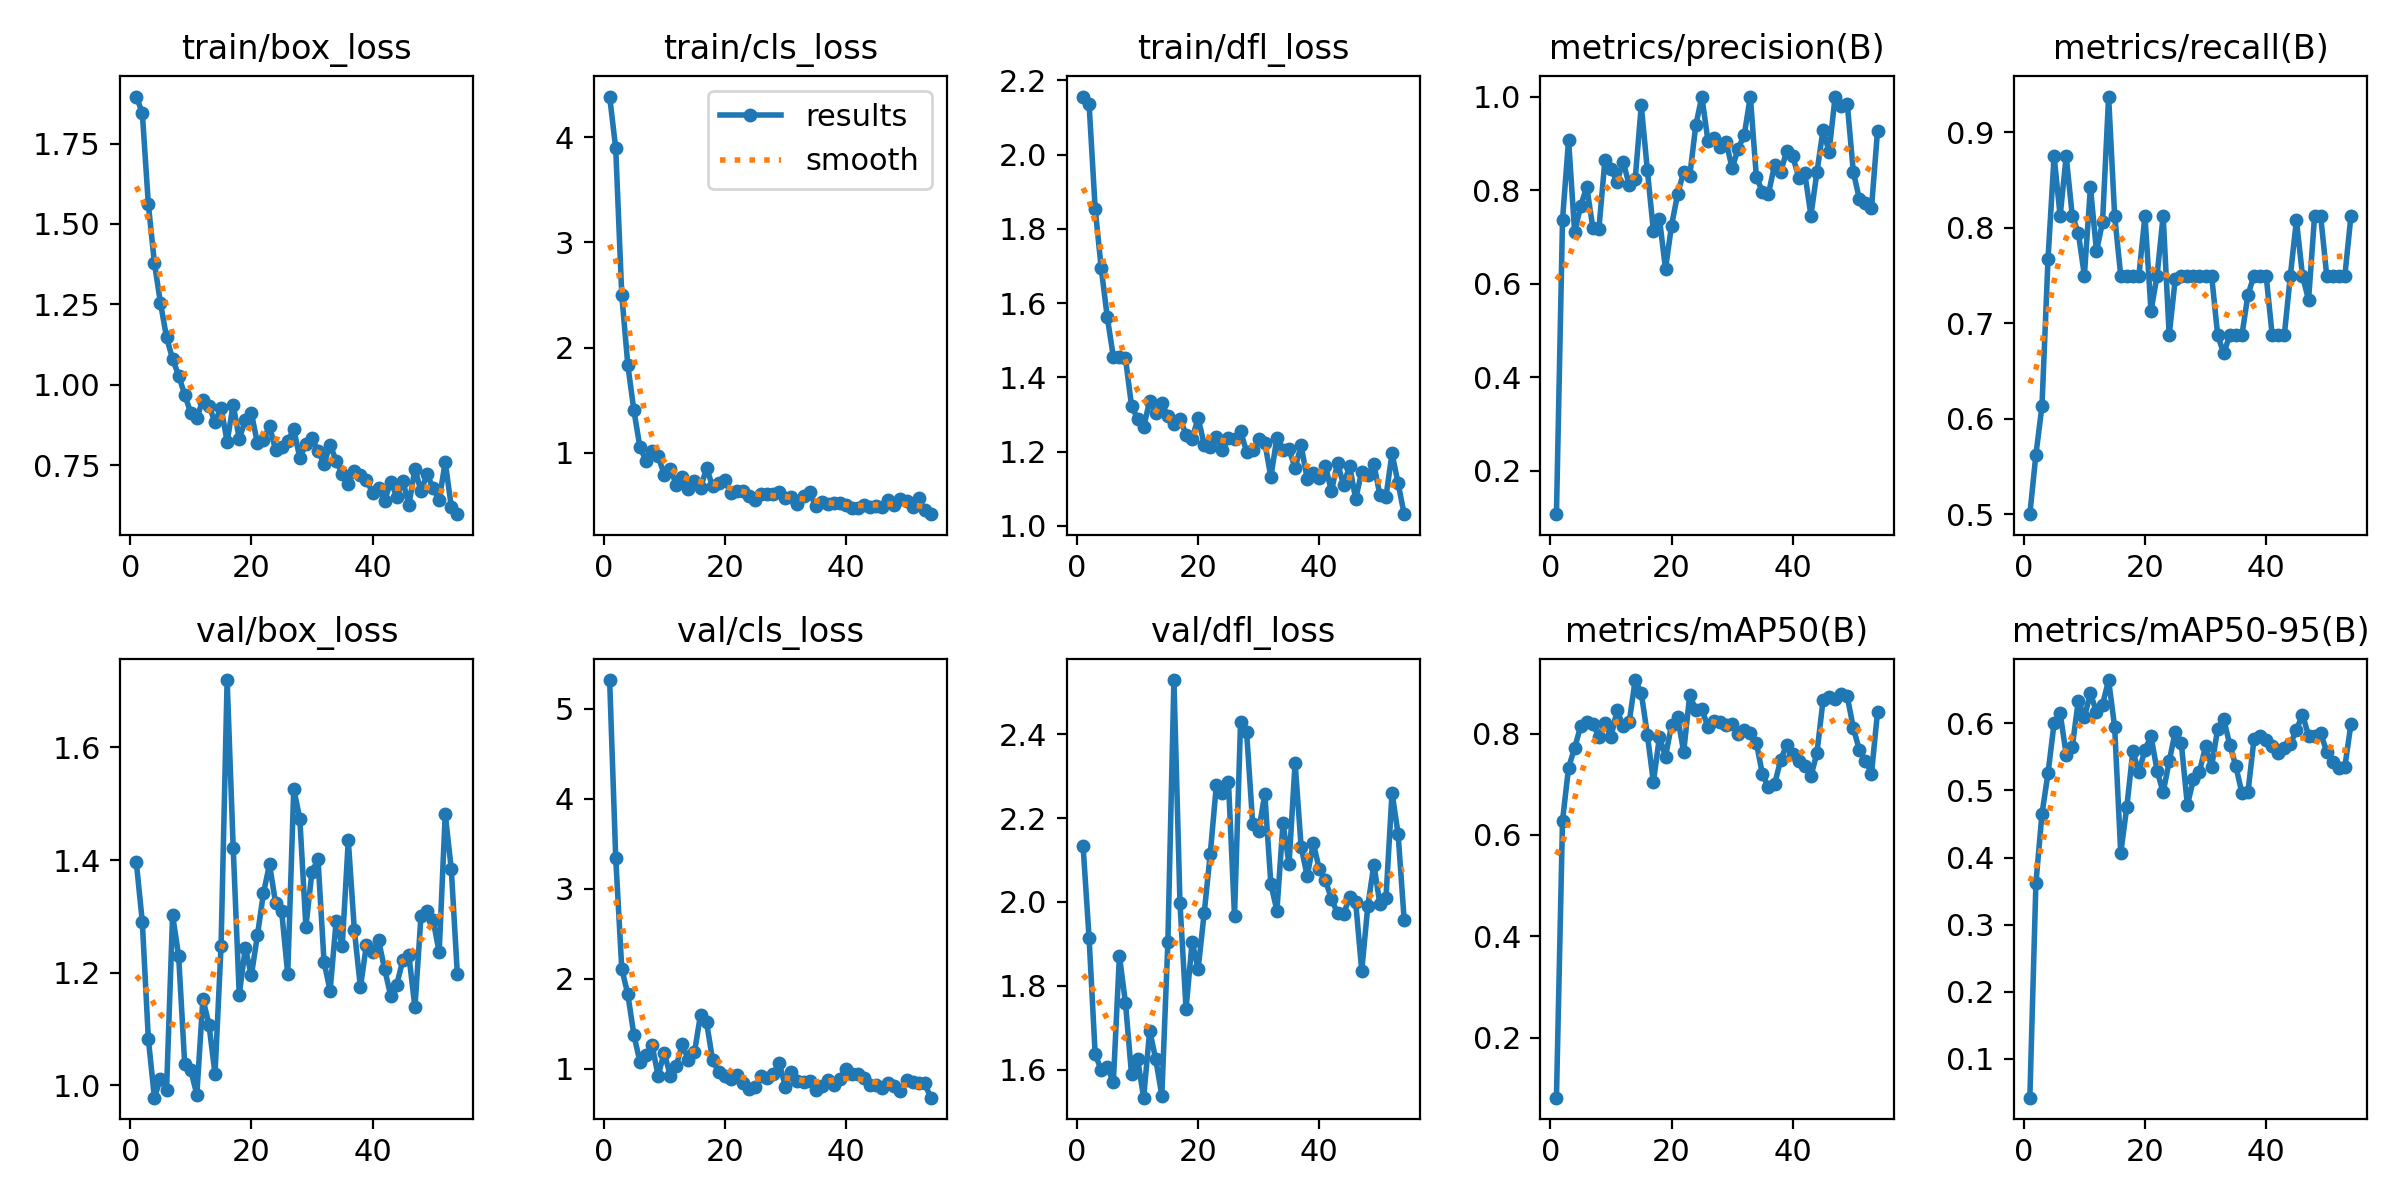

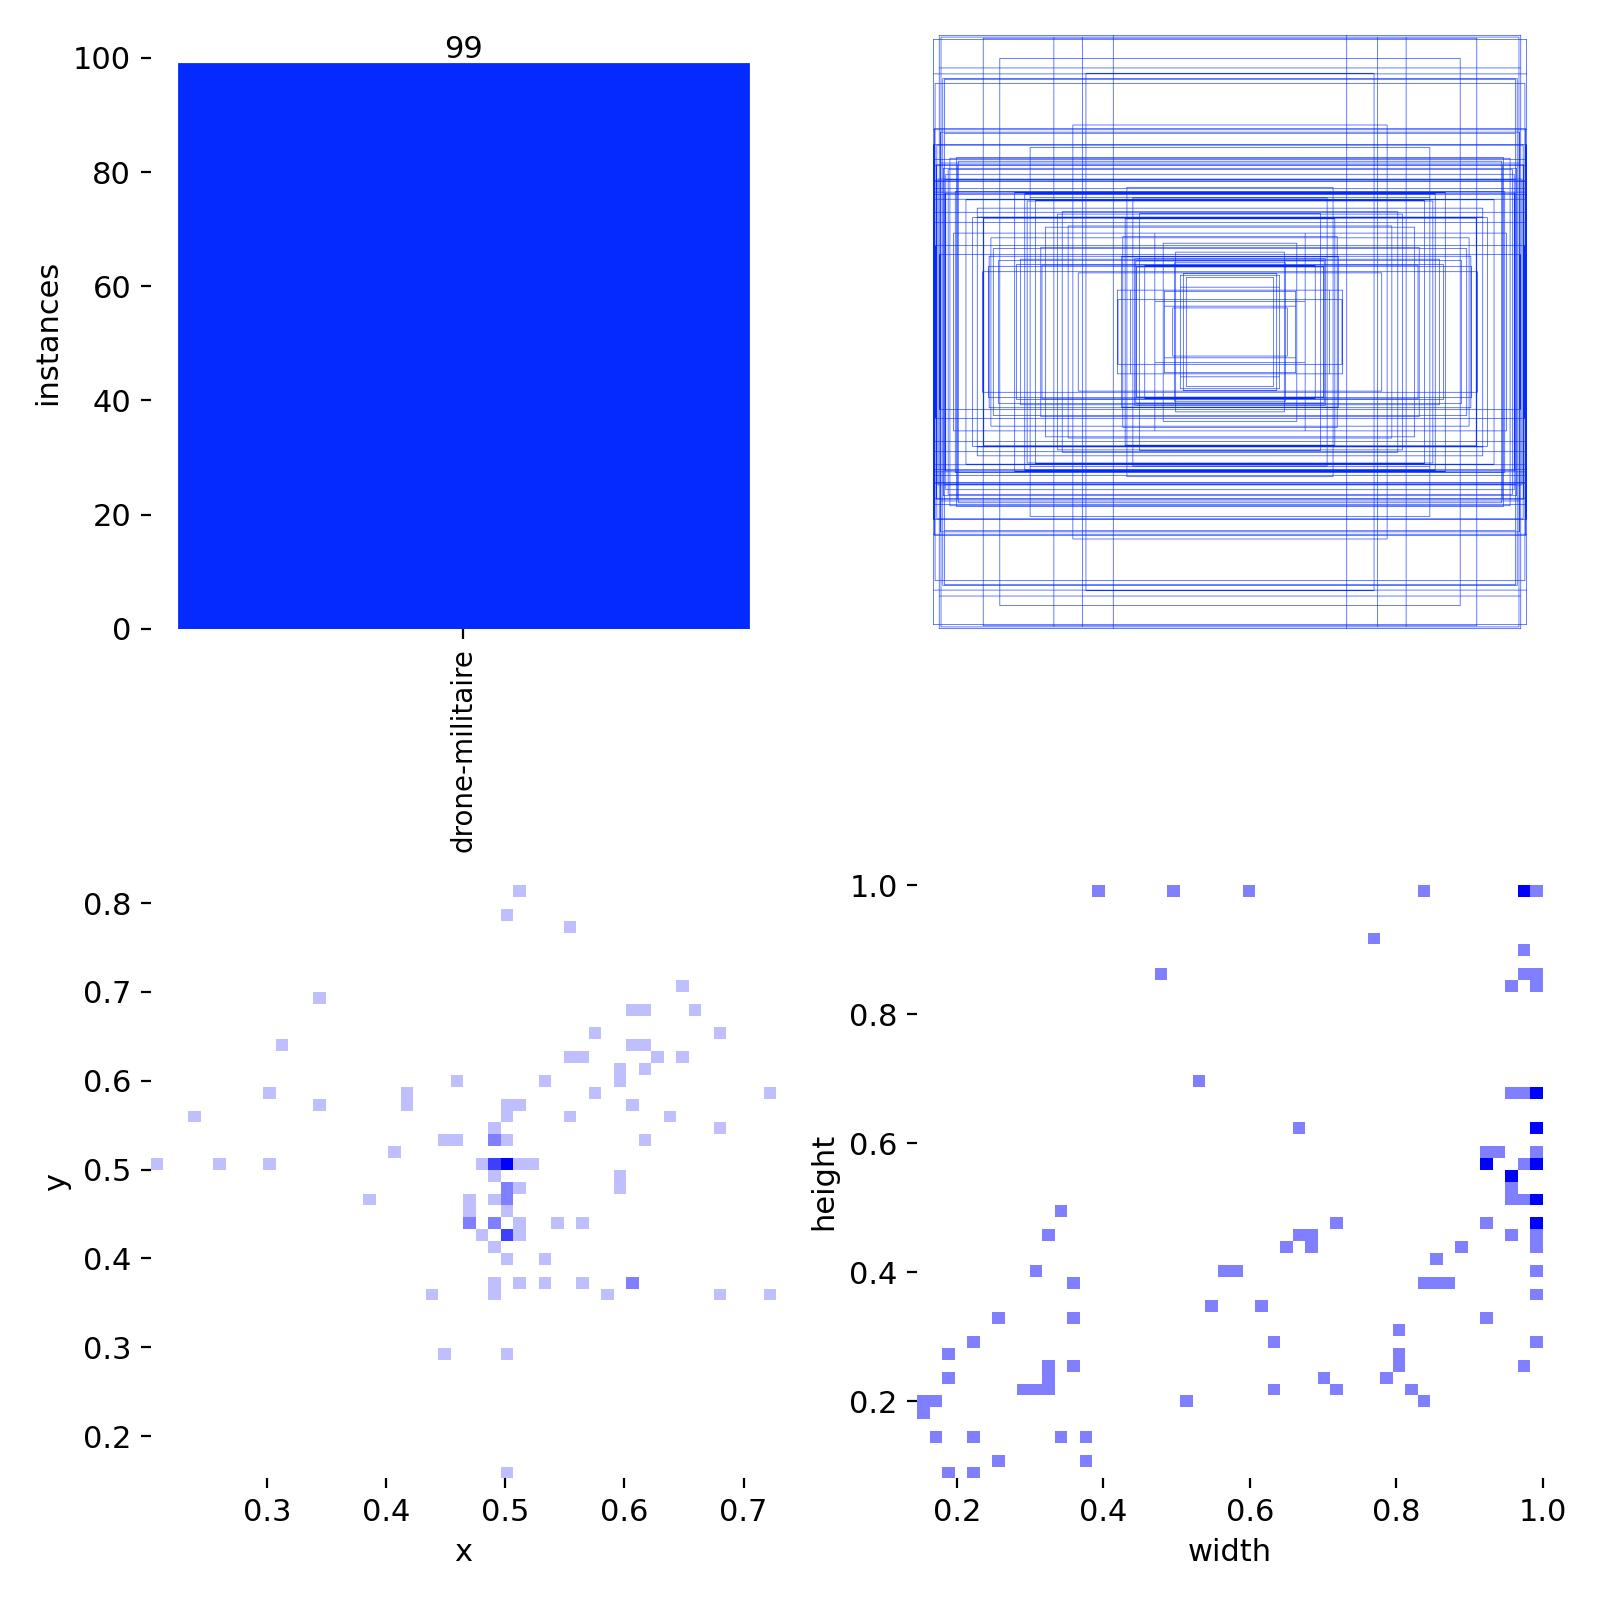

In [ ]:
# Courbes d'entraînement générées par Ultralytics
from IPython.display import Image as IPyImage, display
for f in ["results.png", "labels.jpg"]:
    if (run_dir / f).exists():
        display(IPyImage(filename=str(run_dir / f), width=900))

## 4. Évaluation sur le jeu de test

Métriques exigées par l'énoncé :
- Precision : parmi les drones détectés, combien sont corrects.
- Recall : parmi les vrais drones, combien sont détectés.
- mAP@50 : précision moyenne à un recouvrement (IoU) de 0,5.
- mAP@50-95 : moyenne des mAP pour des IoU de 0,5 à 0,95, la plus stricte.

In [ ]:
best = YOLO(str(run_dir / "weights" / "best.pt"))
metrics = best.val(data=DATA_YAML, split="test", plots=True)

print("========== Performances sur le TEST ==========")
print(f"Precision   : {metrics.box.mp:.4f}")
print(f"Recall      : {metrics.box.mr:.4f}")
print(f"mAP@50      : {metrics.box.map50:.4f}")
print(f"mAP@50-95   : {metrics.box.map:.4f}")

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1900.1±599.2 MB/s, size: 50.3 KB)
val: Scanning /content/dataset/dataset_resplit/test/labels.cache... 16 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 16/16 5.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.6it/s 0.4s
                   all         16         16      0.927      0.875      0.884      0.546
Speed: 0.4ms preprocess, 12.2ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/runs/detect/val-9
========== Performances sur le TEST ==========
Precision   : 0.9270
Recall      : 0.8750
mAP@50      : 0.8840
mAP@50-95   : 0.5463


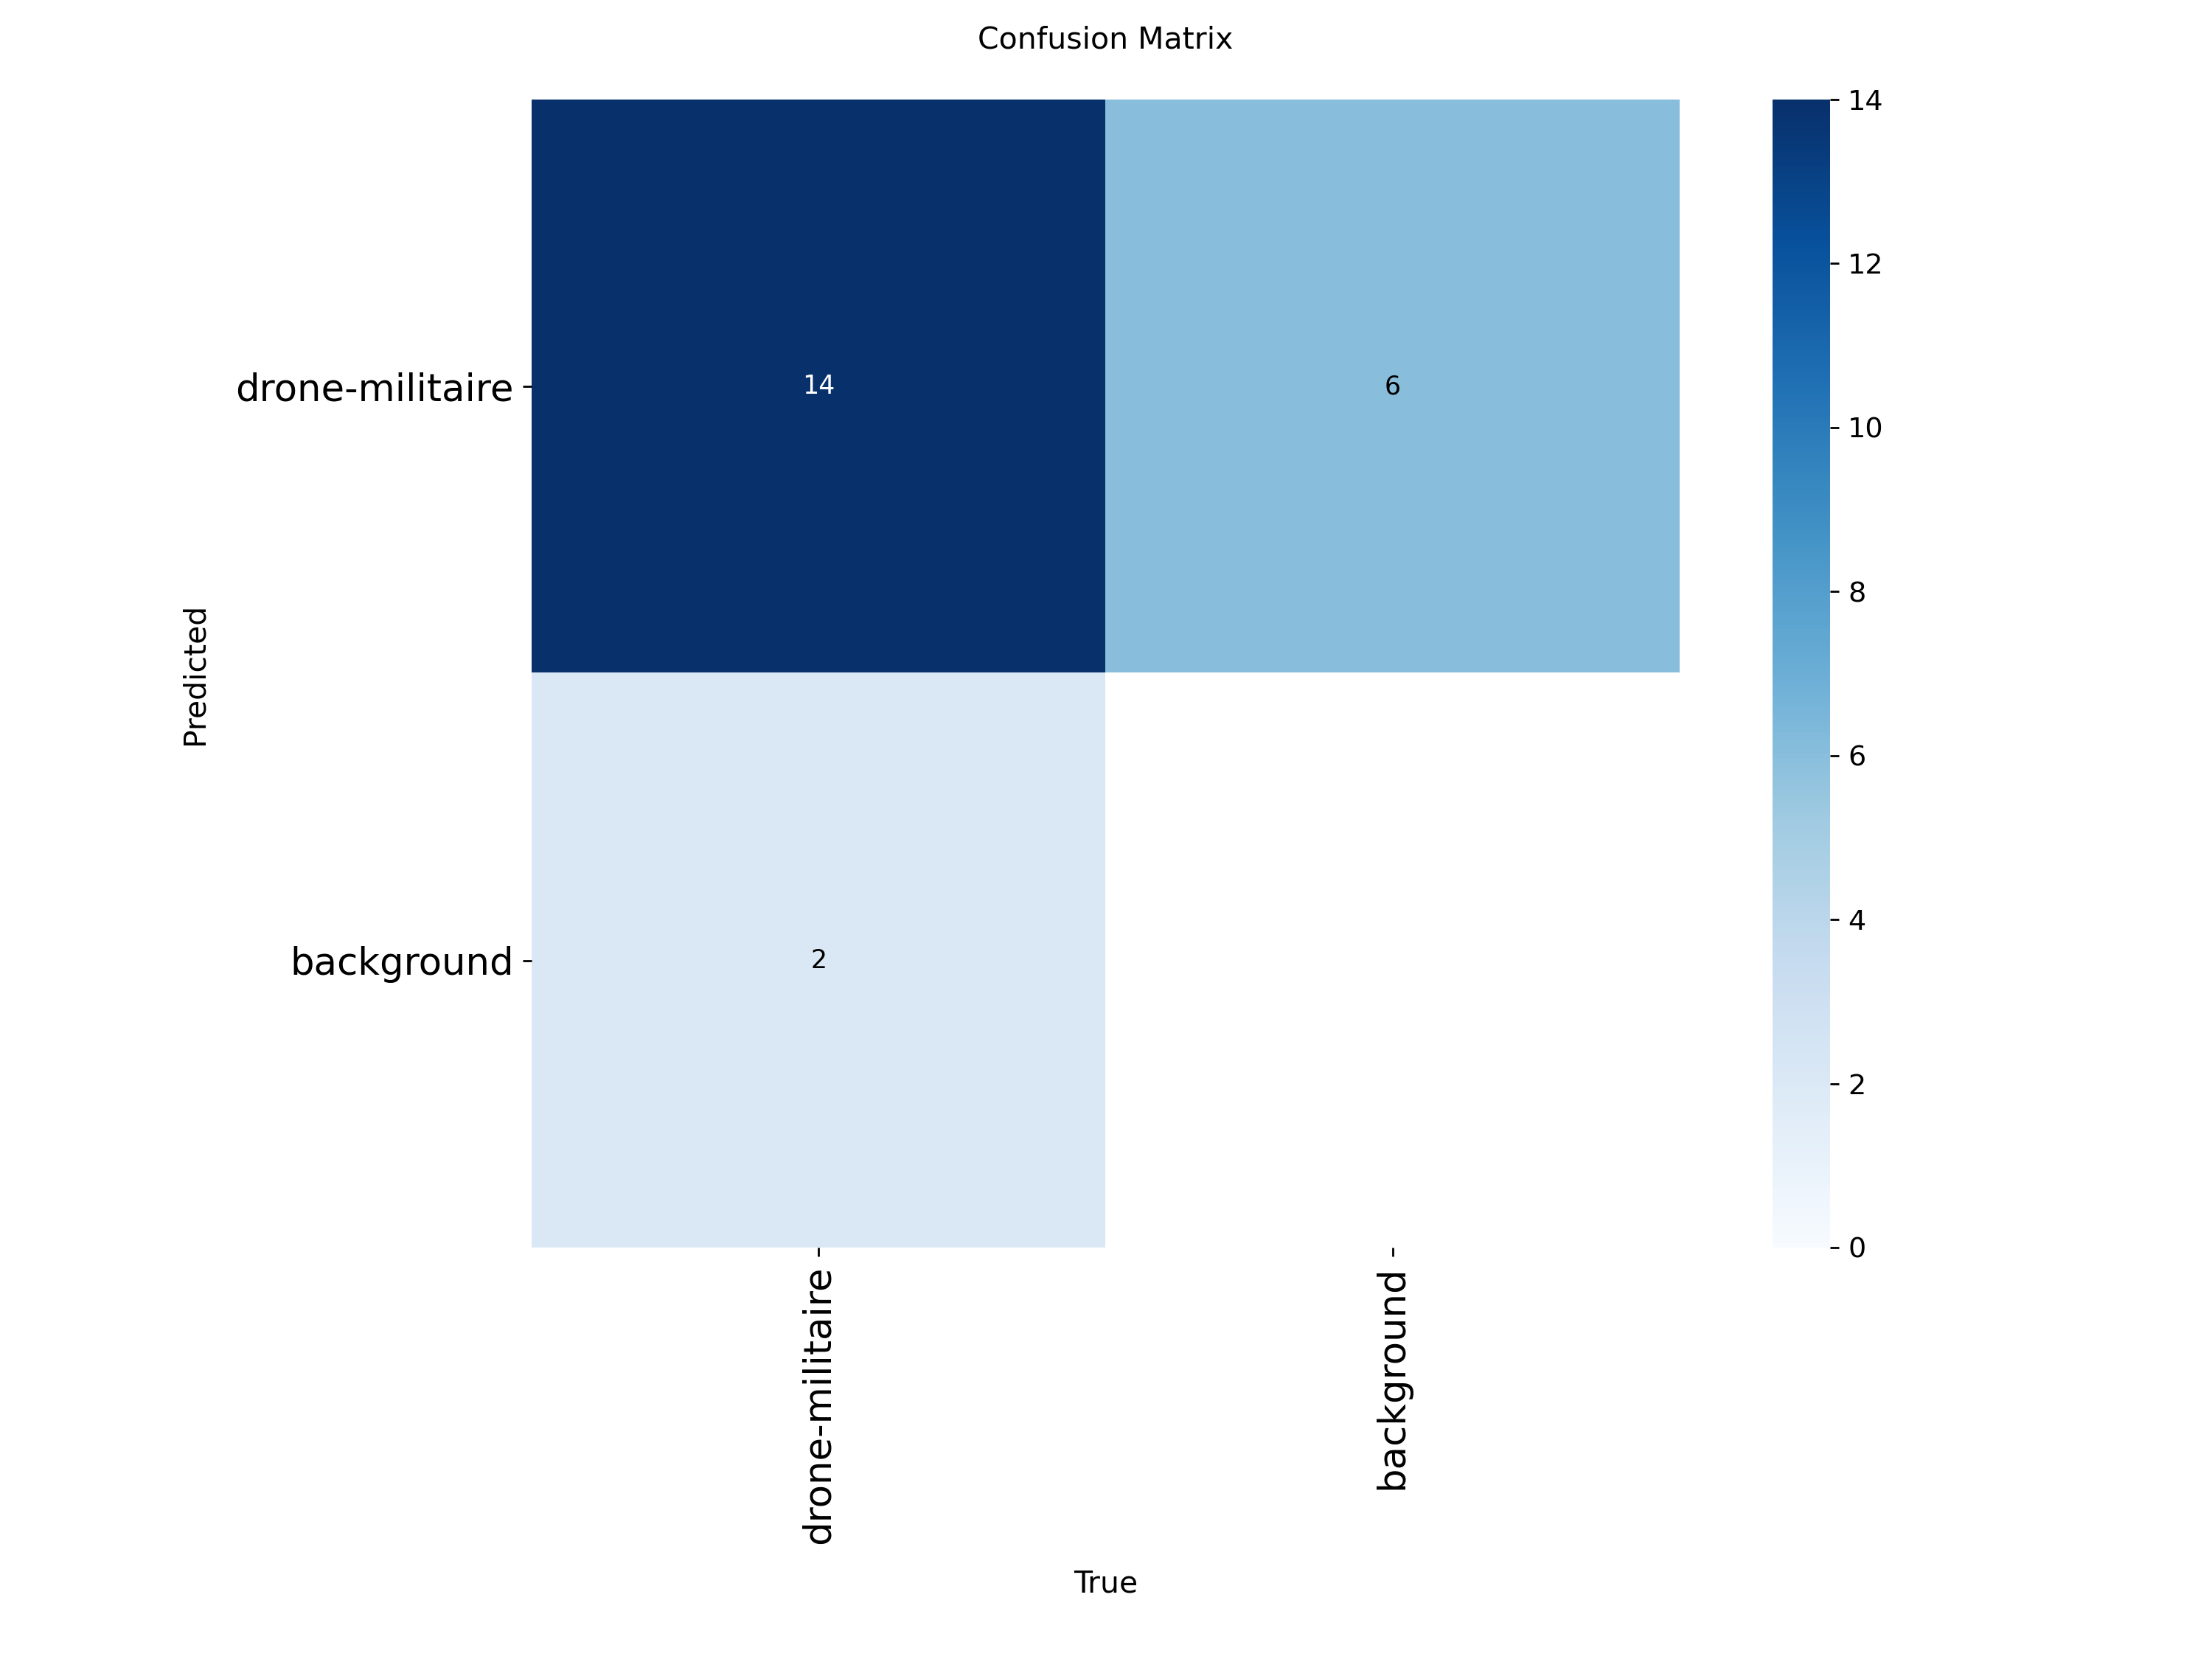

In [ ]:
# Matrice de confusion et courbes PR générées par Ultralytics
eval_dir = Path(metrics.save_dir)
for f in ["confusion_matrix.png", "PR_curve.png", "P_curve.png", "R_curve.png"]:
    if (eval_dir / f).exists():
        display(IPyImage(filename=str(eval_dir / f), width=650))

## 5. Démonstration sur des données inédites

Le modèle final est évalué qualitativement sur des images et une vidéo qui n'ont servi ni à
l'entraînement ni à la validation. Les images de démonstration sont celles du dossier `demo/`,
dont les sources et les licences sont référencées dans `demo/demo_sources.csv`.

In [ ]:
# Démonstration sur des images inédites
DEMO_IMAGES = "/content/demo_images"   # images non utilisées à l'entraînement

import os
if os.path.isdir(DEMO_IMAGES) and os.listdir(DEMO_IMAGES):
    pred = best.predict(source=DEMO_IMAGES, conf=0.25, save=True,
                        project="runs_drone", name="demo_img")
    import glob
    for f in sorted(glob.glob(str(Path(pred[0].save_dir) / "*")))[:4]:
        display(IPyImage(filename=f, width=600))
else:
    print("Aucune image de démonstration trouvée dans", DEMO_IMAGES)

Aucune image de démonstration trouvée dans /content/demo_images


In [ ]:
# Démonstration sur une vidéo inédite
DEMO_VIDEO = "/content/demo.mp4"

if os.path.exists(DEMO_VIDEO):
    vres = best.predict(source=DEMO_VIDEO, conf=0.25, save=True,
                        project="runs_drone", name="demo_video")
    print("Vidéo annotée enregistrée dans :", vres[0].save_dir)
else:
    print("Aucune vidéo de démonstration trouvée à", DEMO_VIDEO)

Aucune vidéo de démonstration trouvée à /content/demo.mp4


## 6. Export du modèle entraîné (livrable)

In [ ]:
import shutil
dest = Path("/content/drone_model"); dest.mkdir(exist_ok=True)

# Poids entraînés + export ONNX : ce sont des livrables du projet.
shutil.copy(run_dir / "weights" / "best.pt", dest / "best.pt")
onnx = best.export(format="onnx")
shutil.copy(onnx, dest / "best.onnx")

# Téléchargement immédiat : une session Colab qui se ferme efface /content.
from google.colab import files
files.download(str(dest / "best.pt"))
files.download(str(dest / "best.onnx"))
print("Modèle exporté et téléchargé :", dest)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/runs/detect/runs_drone/config2_sgd_freeze-3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (18.3 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 2.4s, saved as '/content/runs/detect/runs_drone/config2_sgd_freeze-3/weights/best.onnx' (36.2 MB)

Export complete (3.1s)
Results saved to /content/runs/detect/runs_drone/config2_sgd_freeze-3/weights/best.onnx
Predict:         yolo predict task=detect model=/content/runs/detect/runs_drone/config2_sgd_freeze-3/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/runs_drone/config2_sgd_freeze-3/weights/best.onnx imgsz=640 data=/content/dataset/dataset_resplit/data.yaml  
Visualize:       https://netron.app


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Modèle exporté et téléchargé : /content/drone_model


## 7. Conclusion

La chaîne complète a été réalisée : dataset constitué et annoté sous Roboflow, re-découpage sans fuite de données entre les sous-ensembles, entraînement de YOLOv11 par transfert d'apprentissage, comparaison de deux configurations, évaluation sur le jeu de test (Precision, Recall, mAP@50, mAP@50-95), matrice de confusion et démonstration sur des données inédites.

Limites. Le jeu de test ne compte que 16 images : une seule détection manquée fait varier le recall de plusieurs points, les métriques restent donc bruitées. Les drones de petite taille, occultés ou en arrière-plan restent difficiles à détecter, et trois modèles de drones ne sont représentés que par une image chacun.

Pistes d'amélioration. Élargir le jeu d'images, surtout pour les modèles peu représentés et les drones lointains ; agrandir le jeu de test pour fiabiliser les métriques ; passer à un modèle plus grand (`yolo11m`) ; étoffer le jeu d'images négatives, encore peu nombreuses, pour réduire les faux positifs.